# Deng flux reconstruction - Koppel-Martin Case 1

Nonconforming mixed-dimensional LCG solve on the original thin 3D slab
plus independent 1D fracture mesh, followed by a rectangular-cell Deng
local post-processing.

The postprocessor uses projected `xy` rectangles only as geometry
bookkeeping.  The reconstructed quantity is the thickness-integrated
matrix flux `Q = int q_xy dz`, so no separate 2D CG solve is introduced.


In [1]:
from mpi4py import MPI
import gmsh
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from dolfinx import fem, geometry
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:  # older dolfinx exposed the helpers as dolfinx.io.gmshio
    from dolfinx.io import gmshio
from fenicsx_ii import Average, Circle, LinearProblem

comm = MPI.COMM_WORLD
rank = comm.rank
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)
np.random.seed(1234)

REF = 5
RUN_CONVERGENCE = True
CONV_REFS = [3, 4, 5, 6, 7]
ORDER = 1
THICKNESS = 0.02
Z_FRACTURE = 0.5 * THICKNESS

K_M_VALUE = 1.0
K_F_VALUE = 10.0

# Same endpoints as mixed_dimensional_problem_validation5_nonconforming.ipynb.
# The paper endpoints are (0.25, 0.0) and (0.75, 1.0); the small inset
# avoids circular averaging exactly at the bulk boundary.
FRAC_A = np.array([0.25, 0.01], dtype=float)
FRAC_B = np.array([0.75, 0.99], dtype=float)
TIP_FRAC = 0.05

MESH_CACHE_DIR = pathlib.Path("fracture_problem_nonconforming_km") / "meshes"
OMEGA_MESH_DIR_CANDIDATES = [
    pathlib.Path("."),
    pathlib.Path("fenicsx/code"),
    pathlib.Path("fenicsx/code/fracture problem"),
]

def close_gmsh():
    try:
        if gmsh.isInitialized():
            gmsh.finalize()
    except Exception:
        pass


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def estimate_bulk_h(omega):
    coords = omega.geometry.x
    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf
    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))

def omega_mesh_path(ref):
    name = f"Omega_ex1_{ref}.msh"
    for folder in OMEGA_MESH_DIR_CANDIDATES:
        path = folder / name
        if path.exists():
            return path
    return None

def make_structured_slab_mesh(ref):
    h = 1.0 / (2 ** (ref + 1))
    n = int(round(1.0 / h))
    MESH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = MESH_CACHE_DIR / f"Omega_ex1_{ref}.msh"
    if path.exists():
        return path

    close_gmsh()
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("Omega_KM_case1")
    p1 = gmsh.model.occ.addPoint(0.0, 0.0, 0.0)
    p2 = gmsh.model.occ.addPoint(1.0, 0.0, 0.0)
    p3 = gmsh.model.occ.addPoint(1.0, 1.0, 0.0)
    p4 = gmsh.model.occ.addPoint(0.0, 1.0, 0.0)
    l1 = gmsh.model.occ.addLine(p1, p2)
    l2 = gmsh.model.occ.addLine(p2, p3)
    l3 = gmsh.model.occ.addLine(p3, p4)
    l4 = gmsh.model.occ.addLine(p4, p1)
    cl = gmsh.model.occ.addCurveLoop([l1, l2, l3, l4])
    surf = gmsh.model.occ.addPlaneSurface([cl])
    gmsh.model.occ.synchronize()
    for line in [l1, l2, l3, l4]:
        gmsh.model.mesh.setTransfiniteCurve(line, n + 1)
    gmsh.model.mesh.setTransfiniteSurface(surf)
    gmsh.model.mesh.setRecombine(2, surf)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.model.occ.extrude([(2, surf)], 0.0, 0.0, THICKNESS, numElements=[1], recombine=True)
    gmsh.model.occ.synchronize()
    vols = [tag for _, tag in gmsh.model.getEntities(dim=3)]
    pg = gmsh.model.addPhysicalGroup(3, vols)
    gmsh.model.setPhysicalName(3, pg, "Omega")
    gmsh.model.mesh.generate(3)
    if rank == 0:
        gmsh.write(str(path))
    close_gmsh()
    comm.barrier()
    return path

def gamma_cache_path(ref, h):
    tag = (
        f"ref{ref}_h{h:.8f}"
        f"_a{FRAC_A[0]:.3f}_{FRAC_A[1]:.3f}"
        f"_b{FRAC_B[0]:.3f}_{FRAC_B[1]:.3f}"
    ).replace(".", "p")
    return MESH_CACHE_DIR / f"Gamma_KM_{tag}.msh"

def make_nonconforming_meshes(ref):
    path = omega_mesh_path(ref)
    if path is None:
        path = make_structured_slab_mesh(ref)
    omega = gmshio.read_from_msh(str(path), comm, 0, gdim=3)[0]
    h = estimate_bulk_h(omega)
    h_gamma = 0.5 * h
    gamma_path = gamma_cache_path(ref, h)
    if gamma_path.exists():
        gamma = gmshio.read_from_msh(str(gamma_path), comm, 0, gdim=3)[0]
        return omega, gamma, h, h_gamma, path, gamma_path

    close_gmsh()
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("Gamma_KM_case1")
    p0 = gmsh.model.occ.addPoint(FRAC_A[0], FRAC_A[1], Z_FRACTURE)
    p1 = gmsh.model.occ.addPoint(FRAC_B[0], FRAC_B[1], Z_FRACTURE)
    line = gmsh.model.occ.addLine(p0, p1)
    gmsh.model.occ.synchronize()
    gmsh.model.mesh.setSize([(0, p0), (0, p1)], h_gamma)
    pg = gmsh.model.addPhysicalGroup(1, [line])
    gmsh.model.setPhysicalName(1, pg, "Gamma")
    gmsh.model.mesh.generate(1)
    if rank == 0:
        gamma_path.parent.mkdir(parents=True, exist_ok=True)
        gmsh.write(str(gamma_path))
    gamma = gmshio.model_to_mesh(gmsh.model, comm, 0, gdim=3)[0]
    close_gmsh()
    comm.barrier()
    return omega, gamma, h, h_gamma, path, gamma_path


In [3]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

def real_points_np(s, z_value=Z_FRACTURE):
    s = np.asarray(s, dtype=float).reshape(-1)
    xy = FRAC_A[None, :] + s[:, None] * tau_np[None, :]
    return np.column_stack([xy, np.full(len(xy), z_value)])

def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np

def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np

def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    omega, gamma, h, h_gamma, omega_path, gamma_path = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)
    phi, psi, mu = ufl.TestFunctions(W)
    p_m_trial, p_f_trial, lmbd_trial = ufl.TrialFunctions(W)

    k_m = fem.Constant(
        omega,
        np.array(
            [[K_M_VALUE, 0.0, 0.0],
             [0.0, K_M_VALUE, 0.0],
             [0.0, 0.0, 0.0]],
            dtype=np.float64,
        ),
    )
    k_f = fem.Constant(gamma, K_F_VALUE)
    dx = ufl.Measure("dx", domain=omega)
    dx_f = ufl.Measure("dx", domain=gamma)

    R_circle = min(0.49 * THICKNESS, 0.25 * h, 0.01)
    q_degree = 16
    restriction_trial = Circle(gamma, R_circle, degree=q_degree)
    restriction_test = Circle(gamma, R_circle, degree=q_degree)
    q_el = basix.ufl.quadrature_element(gamma.basix_cell(), value_shape=(), degree=q_degree)
    Rs = fem.functionspace(gamma, q_el)
    avg_pm = Average(p_m_trial, restriction_trial, Rs)
    avg_phi = Average(phi, restriction_test, Rs)

    a = (
        ufl.inner(k_m * ufl.grad(p_m_trial), ufl.grad(phi)) * dx
        - lmbd_trial * avg_phi * dx_f
        + ufl.inner(k_f * ufl.grad(p_f_trial), ufl.grad(psi)) * dx_f
        + lmbd_trial * psi * dx_f
        + avg_pm * mu * dx_f
        - p_f_trial * mu * dx_f
    )
    L = (
        fem.Constant(omega, 0.0) * phi * dx
        + fem.Constant(gamma, 0.0) * psi * dx_f
        + fem.Constant(gamma, 0.0) * mu * dx_f
    )

    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())
    tol = 1e-10 * max(xmax - xmin, ymax - ymin)
    left_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
    pbc = fem.Function(V_m)
    pbc.x.array[left_dofs] = 1.0
    pbc.x.array[right_dofs] = 4.0
    bc_pm = fem.dirichletbc(pbc, all_dofs)

    tol_g = 1e-10 * max(np.ptp(gamma.geometry.x[:, 0]), np.ptp(gamma.geometry.x[:, 1]))
    tip1_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.isclose(x[0], FRAC_A[0], atol=tol_g) & np.isclose(x[1], FRAC_A[1], atol=tol_g),
    )
    tip2_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.isclose(x[0], FRAC_B[0], atol=tol_g) & np.isclose(x[1], FRAC_B[1], atol=tol_g),
    )
    pfbc = fem.Function(V_f)
    pfbc.x.array[tip1_dofs] = 1.0
    pfbc.x.array[tip2_dofs] = 4.0
    bc_pf = fem.dirichletbc(pfbc, np.unique(np.concatenate([tip1_dofs, tip2_dofs])))

    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
    }
    if verbose:
        petsc_options["ksp_monitor"] = None
    problem = LinearProblem(
        a,
        L,
        bcs=[bc_pm, bc_pf],
        petsc_options_prefix=f"km_case1_ref{ref}_",
        petsc_options=petsc_options,
    )
    p_m, p_f, lmbd = problem.solve()
    p_m.name = "p_m"
    p_f.name = "p_gamma"
    lmbd.name = "lambda_h"
    return {
        "ref": ref,
        "omega": omega,
        "gamma": gamma,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "k_f": k_f,
        "h": h,
        "h_gamma": h_gamma,
        "R_circle": R_circle,
        "omega_path": omega_path,
        "gamma_path": gamma_path,
        "bbox": (xmin, xmax, ymin, ymax),
        "ndof_total": (
            V_m.dofmap.index_map.size_global
            + V_f.dofmap.index_map.size_global
            + V_l.dofmap.index_map.size_global
        ),
    }

t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=False)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(f"ref={sol['ref']} h={sol['h']:.3e} h_gamma={sol['h_gamma']:.3e} total dofs={sol['ndof_total']}")
omega = sol["omega"]; gamma = sol["gamma"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


Info    : Reading 'Omega_ex1_5.msh'...
Info    : 27 entities
Info    : 8450 nodes
Info    : 4096 elements
Info    : Done reading 'Omega_ex1_5.msh'
Info    : Reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref5_h0p01562500_a0p250_0p010_b0p750_0p990.msh'...
Info    : 3 entities
Info    : 142 nodes
Info    : 141 elements
Info    : Done reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref5_h0p01562500_a0p250_0p010_b0p750_0p990.msh'
LCG solve complete in 3.63 s
ref=5 h=1.562e-02 h_gamma=7.812e-03 total dofs=8734


In [4]:
def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly

def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))

def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)

tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

cell_polys = []
for verts in local_cell_vertices:
    xy = omega_geometry[verts, :2]
    corners = np.array(
        [
            [xy[:, 0].min(), xy[:, 1].min()],
            [xy[:, 0].max(), xy[:, 1].min()],
            [xy[:, 0].max(), xy[:, 1].max()],
            [xy[:, 0].min(), xy[:, 1].max()],
        ],
        dtype=float,
    )
    cell_polys.append(corners)

cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])

def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))

shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("projected slab cells:", num_cells, "unique projected edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)

def as_3d_points(points, z_value=Z_FRACTURE):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.full(points.shape[0], z_value)])

_BBTREE_CACHE = {}

def _get_bbtree(domain):
    # Build the bounding-box tree once per mesh; rebuilding it on every point
    # evaluation was the dominant cost of the CG cell-flux assembly.
    key = id(domain)
    tree = _BBTREE_CACHE.get(key)
    if tree is None:
        tree = _get_bbtree(domain)
        _BBTREE_CACHE[key] = tree
    return tree

def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_3d_points(points)
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out

_Z_G = np.array([0.5 - 0.5 / np.sqrt(3.0), 0.5 + 0.5 / np.sqrt(3.0)], dtype=float)
_Z_W = np.array([0.5, 0.5], dtype=float)

def q_cg_numpy(points):
    # Return thickness-integrated horizontal flux Q(x,y) = int q_xy(x,y,z) dz.
    pts = np.asarray(points, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for zeta, wz in zip(_Z_G, _Z_W):
        z = zeta * THICKNESS
        pts3 = np.column_stack([pts[:, :2], np.full(pts.shape[0], z)])
        vals = eval_fem_function(q_cg_fun, pts3, omega)
        out += wz * vals[:, :2] * THICKNESS
    return out

def f_numpy(points):
    return np.zeros(np.asarray(points).shape[0], dtype=float)


projected slab cells: 4096 unique projected edges: 8320


In [5]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)

t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np

def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))

def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True

def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None

def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0, :2], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals

def lambda_raw_on_s(s_query):
    return eval_fem_function(lmbd, real_points_np(s_query), gamma).reshape(-1)

def integrate_lambda_interval_raw(s0, s1):
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    return float(half * np.sum(lambda_raw_on_s(sq)))

EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)

def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)

lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

# Batched CG cell flux: collect every edge quadrature point across all cells and
# evaluate the thickness-integrated flux in a single call (one bb_tree, one eval
# per z-level) instead of rebuilding the tree for each point. Numerically identical
# to summing integrate_flux_polygon(poly) cell by cell.
_fx_pts, _fx_nw, _fx_cell = [], [], []
for _cid, _poly in enumerate(cell_polys):
    _ctr = _poly.mean(axis=0)
    for _j in range(len(_poly)):
        _x0 = _poly[_j]
        _x1 = _poly[(_j + 1) % len(_poly)]
        _edge = _x1 - _x0
        _nlen = outward_edge_normal(_x0, _x1, _ctr) * edge_length(_x0, _x1)
        for _q, _w in zip(EDGE_XI, EDGE_WI):
            _fx_pts.append(_x0 + _q * _edge)
            _fx_nw.append(_w * _nlen)
            _fx_cell.append(_cid)
_fx_pts = np.asarray(_fx_pts, dtype=float)
_fx_nw = np.asarray(_fx_nw, dtype=float)
_fx_cell = np.asarray(_fx_cell, dtype=np.int64)
_fx_Q = q_cg_numpy(_fx_pts)
cell_flux_cg = np.zeros(num_cells, dtype=float)
np.add.at(cell_flux_cg, _fx_cell, np.sum(_fx_Q * _fx_nw, axis=1))
cell_source = np.zeros(num_cells, dtype=float)
R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw
else:
    LAMBDA_SIGN = -1.0
    lambda_h_cell_int = -lambda_h_cell_int_raw

def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)

print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with selected lambda_h sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with selected lambda_h sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


fracture-cut cells: 94
auto LAMBDA_SIGN: 1.0
mean |R_CG| with selected lambda_h sign: 0.00021548571758542214
max  |R_CG| with selected lambda_h sign: 0.054934823378534434


In [6]:
# Rectangular Q1 helpers for slab-aware Deng post-processing.
# ORDER=1 is used above so the local Q1 reconstruction matches the CG space.
if ORDER != 1:
    print("Warning: Deng rectangular local solve is Q1-based; ORDER=1 is recommended.")

def q1_phi(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    return np.stack([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], axis=-1)

def q1_grad_ref(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    dxi = np.stack([-(1.0 - eta), (1.0 - eta), -eta, eta], axis=-1)
    deta = np.stack([-(1.0 - xi), -xi, (1.0 - xi), xi], axis=-1)
    return np.stack([dxi, deta], axis=-1)

def q1_grad_phys(xi_eta, hx, hy):
    g = q1_grad_ref(xi_eta).astype(float)
    g[..., 0] /= hx
    g[..., 1] /= hy
    return g

_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)

def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_G3):
        for j, eta in enumerate(_G3):
            pts.append([xi, eta])
            weights.append(_W3[i] * _W3[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)

def ref_from_phys(cell, x):
    x0, y0 = cell["xy"][0]
    return np.array([(x[0] - x0) / cell["hx"], (x[1] - y0) / cell["hy"]], dtype=float)

def grad_from_coeffs(cell, coeffs, x):
    xi = ref_from_phys(cell, x)
    grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
    return grads.T @ coeffs

def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)

def prepare_rect_data_from_slab():
    dof_coords = V_m.tabulate_dof_coordinates()
    dofmap = V_m.dofmap
    pvals = p_m.x.array
    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, poly in enumerate(cell_polys):
        x0, y0 = poly[0]
        x1, y1 = poly[2]
        corners = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        vids = np.array([get_vid(corner) for corner in corners], dtype=np.int32)
        u4 = np.zeros(4, dtype=float)
        cdofs = dofmap.cell_dofs(ci)
        ccoords = dof_coords[cdofs]
        cvals = pvals[cdofs]
        for k, corner in enumerate(corners):
            pt = np.array([corner[0], corner[1], Z_FRACTURE], dtype=float)
            dist = np.linalg.norm(ccoords - pt[None, :], axis=1)
            u4[k] = float(cvals[np.argmin(dist)])
        cells.append({
            "xy": corners,
            "poly": np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float),
            "vids": vids,
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "uvals": u4,
            "cell_id": ci,
        })

    edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
    edge_to_cells = {}
    for ci, cell in enumerate(cells):
        for e, (a, b) in enumerate(edge_defs):
            key = tuple(sorted((int(cell["vids"][a]), int(cell["vids"][b]))))
            edge_to_cells.setdefault(key, []).append((ci, e))
    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)
    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": len(vertices_xy),
    }

rect = prepare_rect_data_from_slab()
print("rectangular slab cells:", rect["num_cells"], "vertices:", rect["num_vertices"])


rectangular slab cells: 4096 vertices: 4225


In [7]:
def integrate_segment_basis_flux(cell, a, b, n_out):
    seg_len = edge_length(a, b)
    out = np.zeros(4, dtype=float)
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        xi = ref_from_phys(cell, x)
        grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
        out += w * (-(THICKNESS * K_M_VALUE) * (grads @ n_out)) * seg_len
    return out

def local_kgrad_dot_n(cell, coeffs, x, n_out):
    grad = grad_from_coeffs(cell, coeffs, x)
    return float(np.dot(THICKNESS * K_M_VALUE * grad, n_out))

def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = THICKNESS * K_M_VALUE * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        val_nb = THICKNESS * K_M_VALUE * grad_from_coeffs(rect["cells"][nb], rect["cells"][nb]["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))

def segment_flux(cell, coeffs, a, b, n_out):
    seg_len = edge_length(a, b)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        grad = grad_from_coeffs(cell, coeffs, x)
        flux += w * np.dot(-(THICKNESS * K_M_VALUE) * grad, n_out) * seg_len
    return float(flux)

def integrate_lambda_phi_interval(cell, s0, s1):
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * _G3 * 2.0 - half
    # Equivalent to midpoint +/- half * [-sqrt(3/5), 0, sqrt(3/5)].
    sq = mid + half * np.array([-np.sqrt(3.0 / 5.0), 0.0, np.sqrt(3.0 / 5.0)])
    weights = np.array([5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0])
    pts = real_points_np(sq)[:, :2]
    lam = lambda_h_on_s(sq)
    out = np.zeros(4, dtype=float)
    for x, w, lv in zip(pts, weights, lam):
        xi = ref_from_phys(cell, x)
        out += half * w * lv * q1_phi(xi[None, :])[0]
    return out

def integrate_lambda_interval_signed(s0, s1):
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    return float(half * np.sum(lambda_h_on_s(sq)))

def deng_postprocess_rect_fracture(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    qp, qw = quad_points_weights()
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    dirichlet_tol = 1e-12

    for ci in tqdm(range(rect["num_cells"]), desc="Deng rectangular slab local solves"):
        cell = rect["cells"][ci]
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        centroid = cell["centroid"]
        uvals = cell["uvals"]

        B = np.zeros((4, 4), dtype=float)
        source_t = np.zeros(4, dtype=float)
        source_phi = np.zeros(4, dtype=float)
        a_term = np.zeros(4, dtype=float)
        e_I = np.zeros(4, dtype=float)
        e_phi = np.zeros(4, dtype=float)

        X_phys = xy[0] + qp * np.array([hx, hy])
        grads_q = q1_grad_phys(qp, hx, hy)
        grad_u_q = np.einsum("qjd,j->qd", grads_q, uvals)
        a_term += area * np.einsum("q,qjd,qd->j", qw, THICKNESS * K_M_VALUE * grads_q, grad_u_q)

        for gi in range(4):
            vi = xy[gi]
            vn = xy[next_ccw[gi]]
            vp = xy[prev_ccw[gi]]
            mid_next = 0.5 * (vi + vn)
            mid_prev = 0.5 * (vi + vp)
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_t[gi] += integrate_lambda_interval_signed(s0, s1)
            for midp in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                B[gi, :] += integrate_segment_basis_flux(cell, centroid, midp, n_seg)

        for s0, s1 in fracture_intervals_in_polygon(cell["poly"]):
            source_phi += integrate_lambda_phi_interval(cell, s0, s1)

        for (a_id, b_id) in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            edge_key = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, b)
            for t, w in zip(_G3, _W3):
                x = a + t * (b - a)
                xi = ref_from_phys(cell, x)
                phi_edge = q1_phi(xi[None, :])[0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                e_phi += w * avg * phi_edge * seg_len
            for gi, other in [(a_id, b_id), (b_id, a_id)]:
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_G3, _W3):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                    e_I[gi] += w * avg * half_len

        rhs = source_t - source_phi + a_term + e_I - e_phi
        fixed = {}
        for li, xyi in enumerate(xy):
            if abs(xyi[0]) < dirichlet_tol or abs(xyi[0] - 1.0) < dirichlet_tol:
                fixed[li] = uvals[li]

        A = B.copy()
        bvec = rhs.copy()
        for lid, val in fixed.items():
            bvec -= A[:, lid] * val
        free = [i for i in range(4) if i not in fixed]
        coeffs = np.zeros(4, dtype=float)
        for lid, val in fixed.items():
            coeffs[lid] = val
        if free:
            coeffs[np.asarray(free)] = np.linalg.lstsq(A[:, free], bvec, rcond=None)[0]

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "rhs": rhs.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec

t0 = time.perf_counter()
local_fluxes, coef_glob, p_rec = deng_postprocess_rect_fracture(rect)
print(f"Deng post-processing time: {time.perf_counter() - t0:.2f} s")


Deng rectangular slab local solves: 100%|██████████| 4096/4096 [00:19<00:00, 204.86it/s]

Deng post-processing time: 20.01 s


In [8]:
def compute_lce_per_element_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n = outward_edge_normal(a, b, centroid)
            flux += segment_flux(cell, coeffs, a, b, n)
        source = lambda_h_cell_int[cell["cell_id"]]
        R[ci] = flux - source
    return R

def compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            centroid = cell["centroid"]
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for midp in [mid_next, mid_prev]:
                n = normal_from_C_to_ti(centroid, midp, vi)
                flux_sum += segment_flux(cell, coeffs, centroid, midp, n)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R

def boundary_vertex_mask_rect(rect):
    xy = rect["vertices_xy"]
    tol = 1e-12
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )

def residual_stats(vals, ids=None):
    vals = np.asarray(vals if ids is None else vals[ids], dtype=float)
    return {
        "mean": float(np.mean(np.abs(vals))),
        "median": float(np.median(np.abs(vals))),
        "max": float(np.max(np.abs(vals))),
    }

R_elem_cg = compute_lce_per_element_rect(rect, local_fluxes, use_rec=False)
R_elem_rec = compute_lce_per_element_rect(rect, local_fluxes, use_rec=True)
R_cv_cg = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=False)
R_cv_rec = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True)
frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)
is_bnd = boundary_vertex_mask_rect(rect)
interior_vertex_ids = np.where(~is_bnd)[0]

print("Element-wise residual R_K")
print("  CG  :", residual_stats(R_elem_cg))
print("  Deng:", residual_stats(R_elem_rec))
print("Fracture-cut element residual R_K")
print("  CG  :", residual_stats(R_elem_cg, frac_cell_ids))
print("  Deng:", residual_stats(R_elem_rec, frac_cell_ids))
print("Interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, interior_vertex_ids))
print("  Deng:", residual_stats(R_cv_rec, interior_vertex_ids))


Element-wise residual R_K
  CG  : {'mean': 0.00020573448353370676, 'median': 0.0, 'max': 0.054471833874344296}
  Deng: {'mean': 0.0002057344835337068, 'median': 0.0, 'max': 0.054471833874344296}
Fracture-cut element residual R_K
  CG  : {'mean': 0.008964770686745347, 'median': 0.004909454282294581, 'max': 0.054471833874344296}
  Deng: {'mean': 0.008964770686745347, 'median': 0.004909454282294581, 'max': 0.054471833874344296}
Interior control-volume residual R_xi
  CG  : {'mean': 0.00014478788754292176, 'median': 1.5857994411025292e-09, 'max': 0.01680355652602837}
  Deng: {'mean': 3.8144214478761194e-05, 'median': 3.371868756429919e-17, 'max': 0.004639796961632149}


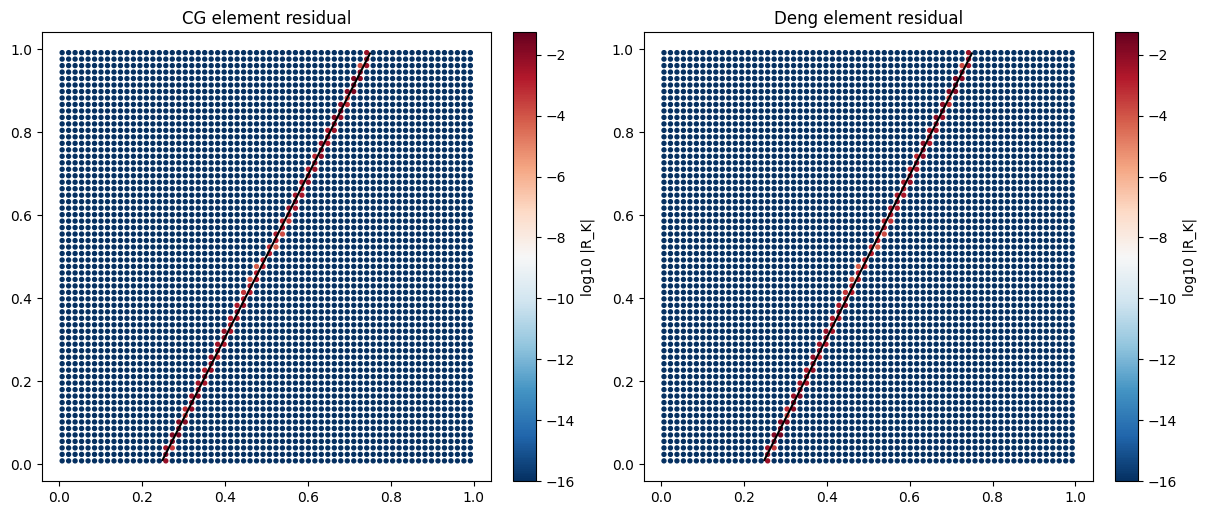

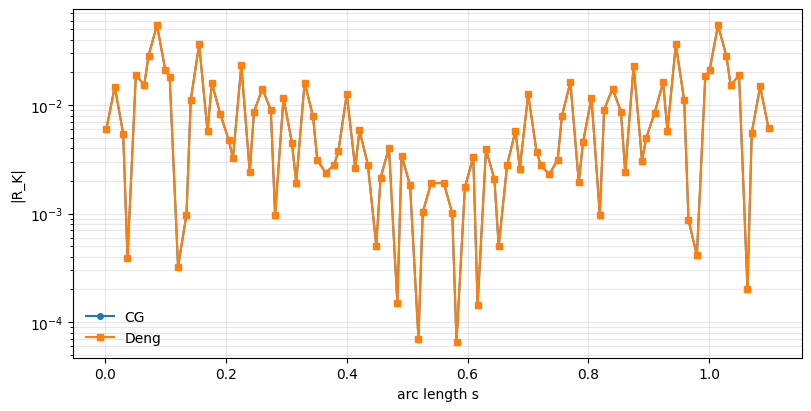

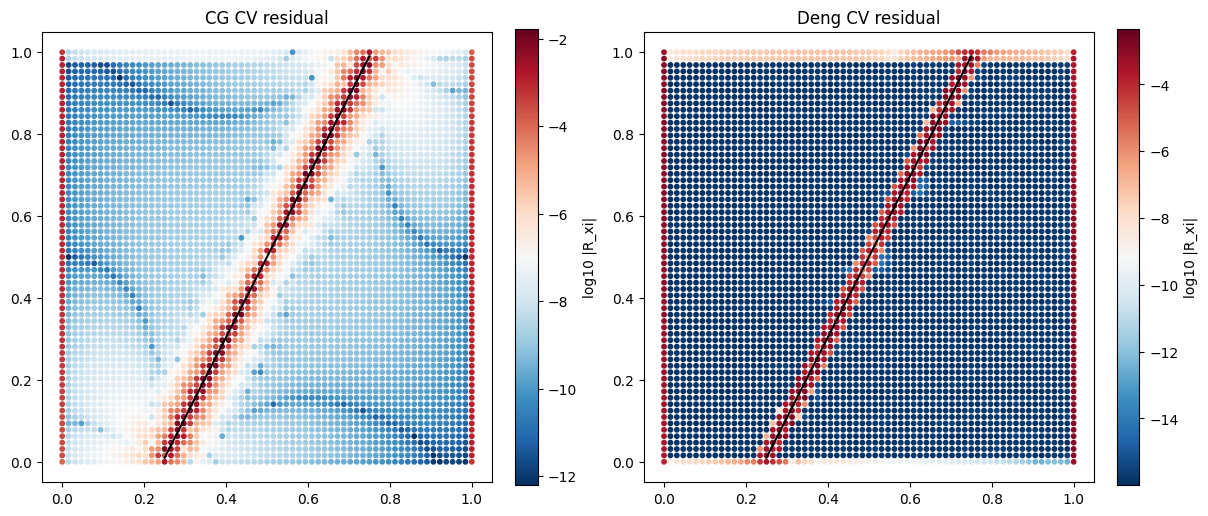

In [9]:
eps = 1e-16
cent = np.vstack([cell["centroid"] for cell in rect["cells"]])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], R_elem_cg, "CG element residual"),
    (axes[1], R_elem_rec, "Deng element residual"),
]:
    sc = ax.scatter(cent[:, 0], cent[:, 1], c=np.log10(np.abs(vals) + eps), s=8, cmap="RdBu_r")
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, label="log10 |R_K|")
plt.show()

if len(frac_cell_ids):
    s_frac = s_coord_np(cent[frac_cell_ids])
    idx = np.argsort(s_frac)
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.semilogy(s_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + eps, "o-", ms=4, label="CG")
    ax.semilogy(s_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + eps, "s-", ms=4, label="Deng")
    ax.set_xlabel("arc length s")
    ax.set_ylabel("|R_K|")
    ax.legend(frameon=False)
    ax.grid(True, which="both", alpha=0.3)
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
xyv = rect["vertices_xy"]
for ax, vals, title in [
    (axes[0], R_cv_cg, "CG CV residual"),
    (axes[1], R_cv_rec, "Deng CV residual"),
]:
    sc = ax.scatter(xyv[:, 0], xyv[:, 1], c=np.log10(np.abs(vals) + eps), s=10, cmap="RdBu_r")
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, label="log10 |R_xi|")
plt.show()


In [10]:
outdir = pathlib.Path("result_koppel_martin_case1_deng")
outdir.mkdir(exist_ok=True)
np.savez(
    outdir / "diagnostics.npz",
    centroids=np.vstack([cell["centroid"] for cell in rect["cells"]]),
    vertices=rect["vertices_xy"],
    R_elem_cg=R_elem_cg,
    R_elem_deng=R_elem_rec,
    R_cv_cg=R_cv_cg,
    R_cv_deng=R_cv_rec,
    frac_cell_ids=frac_cell_ids,
    p_rec=p_rec,
    LAMBDA_SIGN=LAMBDA_SIGN,
    FRAC_A=FRAC_A,
    FRAC_B=FRAC_B,
    thickness=THICKNESS,
)
print("saved:", outdir)


saved: result_koppel_martin_case1_deng


## Convergence analysis

Köppel-Martin Case 1 has no manufactured exact solution in this notebook, so this section reports residual convergence versus mesh refinement: element-wise local balance, fracture-cut element balance, and interior control-volume balance before and after Deng reconstruction.


In [12]:
def convergence_rate(errors, hs):
    errors = np.asarray(errors, dtype=float)
    hs = np.asarray(hs, dtype=float)
    rates = [np.nan]
    for e0, e1, h0, h1 in zip(errors[:-1], errors[1:], hs[:-1], hs[1:]):
        if e0 > 0.0 and e1 > 0.0 and h0 > 0.0 and h1 > 0.0 and h0 != h1:
            rates.append(float(np.log(e0 / e1) / np.log(h0 / h1)))
        else:
            rates.append(np.nan)
    return rates

def fmt_rate(value):
    return "-" if not np.isfinite(value) else f"{value:.2f}"

def residual_stats_n(values, ids=None):
    vals = np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float)
    if vals.size == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    vals = np.abs(vals)
    return {
        "n": int(vals.size),
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "max": float(np.max(vals)),
    }

def fracture_vertex_ids_rect(rect_data, frac_ids, interior_ids):
    mask = np.zeros(rect_data["num_vertices"], dtype=bool)
    for ci in np.asarray(frac_ids, dtype=np.int32):
        mask[rect_data["cells"][int(ci)]["vids"]] = True
    return np.intersect1d(np.where(mask)[0], np.asarray(interior_ids, dtype=np.int32))

def activate_km_case(sol_case, order=ORDER, verbose=False):
    global sol, omega, gamma, V_m, V_f, V_l, p_m, p_f, lmbd, k_m, h, h_est
    global xmin, xmax, ymin, ymax, tdim, gdim, omega_geometry, num_cells, local_cell_vertices
    global cell_polys, cell_centroids, cell_areas, shadow_edges, Wq, q_cg_fun
    global t_min, t_max, GHOST_START, GHOST_END
    global lambda_h_cell_int_raw, gamma_facet_records, cell_flux_cg, cell_source
    global LAMBDA_SIGN, lambda_h_cell_int, rect

    sol = sol_case
    omega = sol_case["omega"]
    gamma = sol_case["gamma"]
    V_m = sol_case["V_m"]
    V_f = sol_case["V_f"]
    V_l = sol_case["V_l"]
    p_m = sol_case["p_m"]
    p_f = sol_case["p_f"]
    lmbd = sol_case["lmbd"]
    k_m = sol_case["k_m"]
    h = sol_case["h"]
    h_est = h
    xmin, xmax, ymin, ymax = sol_case["bbox"]

    tdim = omega.topology.dim
    gdim = omega.geometry.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    omega_geometry = omega.geometry.x
    num_cells = omega.topology.index_map(tdim).size_local
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

    cell_polys = []
    for verts in local_cell_vertices:
        xy = omega_geometry[verts, :2]
        corners = np.array(
            [[xy[:, 0].min(), xy[:, 1].min()],
             [xy[:, 0].max(), xy[:, 1].min()],
             [xy[:, 0].max(), xy[:, 1].max()],
             [xy[:, 0].min(), xy[:, 1].max()]],
            dtype=float,
        )
        cell_polys.append(corners)
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])

    shadow_edges = []
    seen_edges = set()
    for poly in cell_polys:
        for j in range(len(poly)):
            key = edge_key(poly[j], poly[(j + 1) % len(poly)])
            if key not in seen_edges:
                seen_edges.add(key)
                shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
    GHOST_START = FRAC_A + t_min * tau_np
    GHOST_END = FRAC_A + t_max * tau_np

    lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
    gamma_facet_records = []
    for cell_id, poly in enumerate(cell_polys):
        for s0, s1 in fracture_intervals_in_polygon(poly):
            lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
            gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

    # Batched CG cell flux (single bb_tree + one eval per z-level); numerically
    # identical to summing integrate_flux_polygon(poly) cell by cell, but avoids
    # rebuilding the tree and querying it one point at a time.
    _fx_pts, _fx_nw, _fx_cell = [], [], []
    for _cid, _poly in enumerate(cell_polys):
        _ctr = _poly.mean(axis=0)
        for _j in range(len(_poly)):
            _x0 = _poly[_j]
            _x1 = _poly[(_j + 1) % len(_poly)]
            _edge = _x1 - _x0
            _nlen = outward_edge_normal(_x0, _x1, _ctr) * edge_length(_x0, _x1)
            for _q, _w in zip(EDGE_XI, EDGE_WI):
                _fx_pts.append(_x0 + _q * _edge)
                _fx_nw.append(_w * _nlen)
                _fx_cell.append(_cid)
    _fx_Q = q_cg_numpy(np.asarray(_fx_pts, dtype=float))
    cell_flux_cg = np.zeros(num_cells, dtype=float)
    np.add.at(cell_flux_cg, np.asarray(_fx_cell, dtype=np.int64),
              np.sum(_fx_Q * np.asarray(_fx_nw, dtype=float), axis=1))
    cell_source = np.zeros(num_cells, dtype=float)
    R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
    R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
    if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
        LAMBDA_SIGN = 1.0
        lambda_h_cell_int = lambda_h_cell_int_raw
    else:
        LAMBDA_SIGN = -1.0
        lambda_h_cell_int = -lambda_h_cell_int_raw

    rect = prepare_rect_data_from_slab()
    if verbose:
        print("projected slab cells:", num_cells, "unique projected edges:", len(shadow_edges))
        print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
        print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
    return rect

def run_deng_km_case(ref, order=ORDER, verbose=False):
    global local_fluxes, coef_glob, p_rec, R_elem_cg, R_elem_rec, R_cv_cg, R_cv_rec
    global frac_cell_ids, is_bnd, interior_vertex_ids

    wall0 = time.perf_counter()
    t0 = time.perf_counter()
    sol_case = solve_lcg_koppel_martin(ref, order, verbose=False)
    t_solve = time.perf_counter() - t0

    t1 = time.perf_counter()
    rect_case = activate_km_case(sol_case, order=order, verbose=verbose)
    t_geom = time.perf_counter() - t1

    t2 = time.perf_counter()
    local_fluxes, coef_glob, p_rec = deng_postprocess_rect_fracture(rect_case)
    t_post = time.perf_counter() - t2

    t3 = time.perf_counter()
    R_elem_cg = compute_lce_per_element_rect(rect_case, local_fluxes, use_rec=False)
    R_elem_rec = compute_lce_per_element_rect(rect_case, local_fluxes, use_rec=True)
    R_cv_cg = compute_lce_per_cv_rect(rect_case, local_fluxes, use_rec=False)
    R_cv_rec = compute_lce_per_cv_rect(rect_case, local_fluxes, use_rec=True)
    frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)
    is_bnd = boundary_vertex_mask_rect(rect_case)
    interior_vertex_ids = np.where(~is_bnd)[0]
    fracture_cv_ids = fracture_vertex_ids_rect(rect_case, frac_cell_ids, interior_vertex_ids)
    t_diag = time.perf_counter() - t3
    t_total = time.perf_counter() - wall0

    stats_elem_cg = residual_stats_n(R_elem_cg)
    stats_elem_rec = residual_stats_n(R_elem_rec)
    stats_elem_frac_cg = residual_stats_n(R_elem_cg, frac_cell_ids)
    stats_elem_frac_rec = residual_stats_n(R_elem_rec, frac_cell_ids)
    stats_cv_cg = residual_stats_n(R_cv_cg, interior_vertex_ids)
    stats_cv_rec = residual_stats_n(R_cv_rec, interior_vertex_ids)
    stats_cv_frac_cg = residual_stats_n(R_cv_cg, fracture_cv_ids)
    stats_cv_frac_rec = residual_stats_n(R_cv_rec, fracture_cv_ids)
    nonfrac_cv_ids = np.setdiff1d(interior_vertex_ids, fracture_cv_ids)
    stats_cv_bulk_cg = residual_stats_n(R_cv_cg, nonfrac_cv_ids)
    stats_cv_bulk_rec = residual_stats_n(R_cv_rec, nonfrac_cv_ids)

    return {
        "ref": int(ref),
        "h": float(sol_case["h"]),
        "h_gamma": float(sol_case["h_gamma"]),
        "dofs_total": int(sol_case["ndof_total"]),
        "num_cells": int(rect_case["num_cells"]),
        "num_vertices": int(rect_case["num_vertices"]),
        "num_frac_cells": int(len(frac_cell_ids)),
        "num_frac_cvs": int(len(fracture_cv_ids)),
        "mean_elem_cg": stats_elem_cg["mean"],
        "mean_elem_rec": stats_elem_rec["mean"],
        "max_elem_cg": stats_elem_cg["max"],
        "max_elem_rec": stats_elem_rec["max"],
        "mean_elem_frac_cg": stats_elem_frac_cg["mean"],
        "mean_elem_frac_rec": stats_elem_frac_rec["mean"],
        "max_elem_frac_cg": stats_elem_frac_cg["max"],
        "max_elem_frac_rec": stats_elem_frac_rec["max"],
        "mean_cv_cg": stats_cv_cg["mean"],
        "mean_cv_rec": stats_cv_rec["mean"],
        "max_cv_cg": stats_cv_cg["max"],
        "max_cv_rec": stats_cv_rec["max"],
        "mean_cv_frac_cg": stats_cv_frac_cg["mean"],
        "mean_cv_frac_rec": stats_cv_frac_rec["mean"],
        "max_cv_frac_cg": stats_cv_frac_cg["max"],
        "max_cv_frac_rec": stats_cv_frac_rec["max"],
        "median_cv_cg": stats_cv_cg["median"],
        "median_cv_rec": stats_cv_rec["median"],
        "mean_cv_bulk_rec": stats_cv_bulk_rec["mean"],
        "median_cv_bulk_rec": stats_cv_bulk_rec["median"],
        "max_cv_bulk_rec": stats_cv_bulk_rec["max"],
        "median_cv_frac_rec": stats_cv_frac_rec["median"],
        "num_bulk_cvs": int(len(nonfrac_cv_ids)),
        "lambda_sign": float(LAMBDA_SIGN),
        "t_solve": float(t_solve),
        "t_geom": float(t_geom),
        "t_post": float(t_post),
        "t_diag": float(t_diag),
        "t_total": float(t_total),
    }

def run_convergence_study(refs=CONV_REFS, order=ORDER):
    rows = []
    for ref in refs:
        print(f"ref={ref} ...", flush=True)
        row = run_deng_km_case(ref, order=order, verbose=False)
        rows.append(row)
        print(
            f"  h={row['h']:.3e}, mean R_K^CG={row['mean_elem_cg']:.3e}, "
            f"mean R_K^D={row['mean_elem_rec']:.3e}, mean R_xi^D={row['mean_cv_rec']:.3e}, "
            f"total={row['t_total']:.2f}s"
        )
    return rows

if RUN_CONVERGENCE:
    conv_results = run_convergence_study(CONV_REFS, ORDER)
else:
    print("RUN_CONVERGENCE = False. Set it to True and rerun this cell for the convergence analysis.")


ref=3 ...


Info    : Reading 'Omega_ex1_3.msh'...
Info    : 27 entities
Info    : 578 nodes
Info    : 256 elements
Info    : Done reading 'Omega_ex1_3.msh'
Info    : Reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref3_h0p06250000_a0p250_0p010_b0p750_0p990.msh'...
Info    : 3 entities
Info    : 37 nodes
Info    : 36 elements
Info    : Done reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref3_h0p06250000_a0p250_0p010_b0p750_0p990.msh'


Deng rectangular slab local solves: 100%|██████████| 256/256 [00:01<00:00, 139.27it/s]


  h=6.250e-02, mean R_K^CG=3.239e-03, mean R_K^D=3.239e-03, mean R_xi^D=5.544e-04, total=5.70s
ref=4 ...
Info    : Reading 'Omega_ex1_4.msh'...
Info    : 27 entities
Info    : 2178 nodes
Info    : 1024 elements
Info    : Done reading 'Omega_ex1_4.msh'
Info    : Reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref4_h0p03125000_a0p250_0p010_b0p750_0p990.msh'...
Info    : 3 entities
Info    : 13 nodes
Info    : 12 elements
Info    : Done reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref4_h0p03125000_a0p250_0p010_b0p750_0p990.msh'


Deng rectangular slab local solves: 100%|██████████| 1024/1024 [00:06<00:00, 167.12it/s]


...

  h=1.562e-02, mean R_K^CG=2.057e-04, mean R_K^D=2.057e-04, mean R_xi^D=3.814e-05, total=35.95s
ref=6 ...
Info    : Reading 'Omega_ex1_6.msh'...
Info    : 27 entities
Info    : 33282 nodes
Info    : 16384 elements
Info    : Done reading 'Omega_ex1_6.msh'
Info    : Reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref6_h0p00781250_a0p250_0p010_b0p750_0p990.msh'...
Info    : 3 entities
Info    : 283 nodes
Info    : 282 elements
Info    : Done reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref6_h0p00781250_a0p250_0p010_b0p750_0p990.msh'


Deng rectangular slab local solves: 100%|██████████| 16384/16384 [01:26<00:00, 190.25it/s]


  h=7.812e-03, mean R_K^CG=5.849e-05, mean R_K^D=5.849e-05, mean R_xi^D=1.018e-05, total=143.67s
ref=7 ...
Info    : Reading 'Omega_ex1_7.msh'...
Info    : 27 entities
Info    : 132098 nodes
Info    : 65536 elements                                                                                      
Info    : Done reading 'Omega_ex1_7.msh'
Info    : Reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref7_h0p00390625_a0p250_0p010_b0p750_0p990.msh'...
Info    : 3 entities
Info    : 565 nodes
Info    : 564 elements
Info    : Done reading 'fracture_problem_nonconforming_km/meshes/Gamma_KM_ref7_h0p00390625_a0p250_0p010_b0p750_0p990.msh'


Deng rectangular slab local solves: 100%|██████████| 65536/65536 [05:50<00:00, 187.11it/s]


  h=3.906e-03, mean R_K^CG=1.525e-05, mean R_K^D=1.525e-05, mean R_xi^D=2.546e-06, total=536.54s



Köppel-Martin Case 1 residual convergence
No exact solution is used here; rates are for residual diagnostics versus h.
ref          h     dofs   mean|R_K CG|    rt    mean|R_K D|    rt   mean|R_xi CG|    rt   mean|R_xi D|    rt   total[s]
-----------------------------------------------------------------------------------------------------------------------
  3  6.250e-02      652      3.239e-03     -      3.239e-03     -       3.674e-03     -      5.544e-04     -      5.704
  4  3.125e-02     2204      5.695e-05  5.83      5.695e-05  5.83       1.997e-05  7.52      3.939e-06  7.14     11.136
  5  1.562e-02     8734      2.057e-04 -1.85      2.057e-04 -1.85       1.448e-04 -2.86      3.814e-05 -3.28     35.946
  6  7.812e-03    33848      5.849e-05  1.81      5.849e-05  1.81       5.599e-05  1.37      1.018e-05  1.91    143.672
  7  3.906e-03   133228      1.525e-05  1.94      1.525e-05  1.94       1.207e-05  2.21      2.546e-06  2.00    536.536

Fracture-focused Deng residual converge

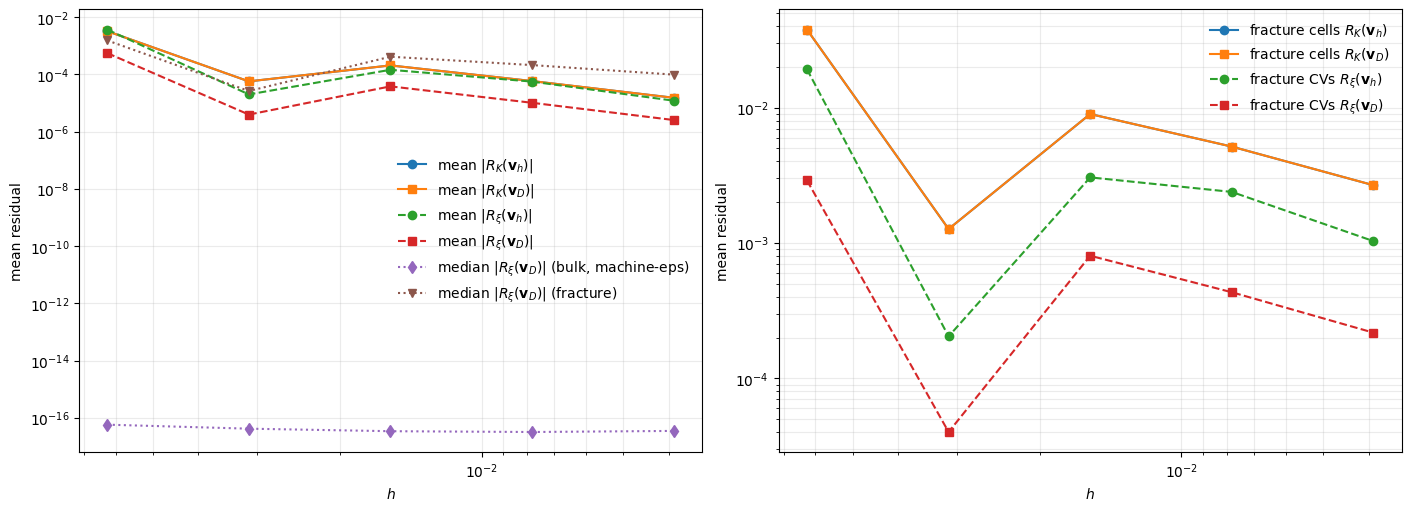

saved: result_koppel_martin_case1_deng/convergence_residuals.npz


In [13]:
hs = [r["h"] for r in conv_results]
rate_elem_cg = convergence_rate([r["mean_elem_cg"] for r in conv_results], hs)
rate_elem_rec = convergence_rate([r["mean_elem_rec"] for r in conv_results], hs)
rate_cv_cg = convergence_rate([r["mean_cv_cg"] for r in conv_results], hs)
rate_cv_rec = convergence_rate([r["mean_cv_rec"] for r in conv_results], hs)
rate_elem_frac_rec = convergence_rate([r["mean_elem_frac_rec"] for r in conv_results], hs)
rate_cv_frac_rec = convergence_rate([r["mean_cv_frac_rec"] for r in conv_results], hs)

print("\nKöppel-Martin Case 1 residual convergence")
print("No exact solution is used here; rates are for residual diagnostics versus h.")
header = (
    f"{'ref':>3} {'h':>10} {'dofs':>8} "
    f"{'mean|R_K CG|':>14} {'rt':>5} "
    f"{'mean|R_K D|':>14} {'rt':>5} "
    f"{'mean|R_xi CG|':>15} {'rt':>5} "
    f"{'mean|R_xi D|':>14} {'rt':>5} {'total[s]':>10}"
)
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} {r['dofs_total']:8d} "
        f"{r['mean_elem_cg']:14.3e} {fmt_rate(rate_elem_cg[i]):>5} "
        f"{r['mean_elem_rec']:14.3e} {fmt_rate(rate_elem_rec[i]):>5} "
        f"{r['mean_cv_cg']:15.3e} {fmt_rate(rate_cv_cg[i]):>5} "
        f"{r['mean_cv_rec']:14.3e} {fmt_rate(rate_cv_rec[i]):>5} {r['t_total']:10.3f}"
    )

print("\nFracture-focused Deng residual convergence")
header = f"{'ref':>3} {'h':>10} {'frac cells':>10} {'frac CVs':>9} {'mean|R_K^D|':>14} {'rt':>5} {'mean|R_xi^D|':>15} {'rt':>5}"
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} {r['num_frac_cells']:10d} {r['num_frac_cvs']:9d} "
        f"{r['mean_elem_frac_rec']:14.3e} {fmt_rate(rate_elem_frac_rec[i]):>5} "
        f"{r['mean_cv_frac_rec']:15.3e} {fmt_rate(rate_cv_frac_rec[i]):>5}"
    )

rate_cv_frac_med = convergence_rate([r["median_cv_frac_rec"] for r in conv_results], hs)
print("\nDeng CV conservation by statistic (median = machine-precision indicator;")
print("the mean is pulled off zero by the O(h) fracture band, so it never reads 1e-16)")
header = (
    f"{'ref':>3} {'h':>10} "
    f"{'interior med':>14} {'bulk med':>14} {'frac med':>14} {'rt':>5} "
    f"{'frac mean':>14} {'interior mean':>14}"
)
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} "
        f"{r['median_cv_rec']:14.3e} {r['median_cv_bulk_rec']:14.3e} "
        f"{r['median_cv_frac_rec']:14.3e} {fmt_rate(rate_cv_frac_med[i]):>5} "
        f"{r['mean_cv_frac_rec']:14.3e} {r['mean_cv_rec']:14.3e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].loglog(hs, [r["mean_elem_cg"] for r in conv_results], "o-", label=r"mean $|R_K(\mathbf{v}_h)|$")
axes[0].loglog(hs, [r["mean_elem_rec"] for r in conv_results], "s-", label=r"mean $|R_K(\mathbf{v}_D)|$")
axes[0].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label=r"mean $|R_\xi(\mathbf{v}_h)|$")
axes[0].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label=r"mean $|R_\xi(\mathbf{v}_D)|$")
axes[0].loglog(hs, [max(r["median_cv_rec"], 1e-18) for r in conv_results], "d:", label=r"median $|R_\xi(\mathbf{v}_D)|$ (bulk, machine-eps)")
axes[0].loglog(hs, [r["median_cv_frac_rec"] for r in conv_results], "v:", label=r"median $|R_\xi(\mathbf{v}_D)|$ (fracture)")
axes[0].invert_xaxis()
axes[0].set_xlabel(r"$h$")
axes[0].set_ylabel("mean residual")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].loglog(hs, [r["mean_elem_frac_cg"] for r in conv_results], "o-", label=r"fracture cells $R_K(\mathbf{v}_h)$")
axes[1].loglog(hs, [r["mean_elem_frac_rec"] for r in conv_results], "s-", label=r"fracture cells $R_K(\mathbf{v}_D)$")
axes[1].loglog(hs, [r["mean_cv_frac_cg"] for r in conv_results], "o--", label=r"fracture CVs $R_\xi(\mathbf{v}_h)$")
axes[1].loglog(hs, [r["mean_cv_frac_rec"] for r in conv_results], "s--", label=r"fracture CVs $R_\xi(\mathbf{v}_D)$")
axes[1].invert_xaxis()
axes[1].set_xlabel(r"$h$")
axes[1].set_ylabel("mean residual")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(frameon=False)
plt.show()

conv_outdir = pathlib.Path("result_koppel_martin_case1_deng")
conv_outdir.mkdir(exist_ok=True)
np.savez(conv_outdir / "convergence_residuals.npz", **{k: np.array([r[k] for r in conv_results]) for k in conv_results[0]})
print("saved:", conv_outdir / "convergence_residuals.npz")